In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import wilson_confint


In [2]:
from cycler import cycler
line_cycler   = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))
marker_cycler = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["none", "none", "none", "none", "none", "none", "none"]) +
                 cycler(marker=["4", "2", "3", "1", "+", "x", "."]))

# Explanatory analysis of the tags

## pre-train

In [3]:
# load data
ptags = pd.read_csv('./data/pre-train_tags.csv',index_col=0)
pre_training_tags = ptags[ptags['agree'] == 1]


In [4]:
pre_training_tags['Cat'].value_counts()

Cat
c     388
do    173
di    164
l     124
t      50
u       2
Name: count, dtype: int64

In [5]:
pre_training_tags['Cat'].value_counts().plot(kind='bar')

<Axes: xlabel='Cat'>

## Fine-tune


In [6]:
# load data
ftags = pd.read_csv('./data/fine-tune_tags.csv',index_col=0)
fine_tuning_tags = ftags[ftags['agree'] == 1]

In [7]:
fine_tuning_tags['Cat'].value_counts()

Cat
do    291
l     284
c     223
di    117
u       8
t       2
Name: count, dtype: int64

In [8]:
fine_tuning_tags['Cat'].value_counts().plot(kind='bar')

<Axes: xlabel='Cat'>

# Pre-training experiments

### Samples memorized per model size and categories - base model attack

tot tags pre train

In [9]:
tot_tags_pre = pre_training_tags[['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count()
tot_tags_pre 
tot_tags_pre['bf16_ep0_p100_em']

Cat
c     388
di    164
do    173
l     124
t      50
u       2
Name: bf16_ep0_p100_em, dtype: int64

#### Heatmpap with absolute values

In [10]:
ep0_cat_fp32 = pre_training_tags[pre_training_tags['15b_ep0_p100_em'] == 1 ][['15b_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep0_p100_em'] == 1 ][['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_i8 = pre_training_tags[pre_training_tags['i8_ep0_p100_em'] == 1 ][['i8_ep0_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_i4 = pre_training_tags[pre_training_tags['i4_ep0_p100_em'] == 1 ][['i4_ep0_p100_em', 'Cat']].groupby('Cat').count()


ep0_cat = ep0_cat_fp32.join(ep0_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep0_cat_i4, rsuffix='_i4').join(ep0_cat_i8, rsuffix='_i8').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat = ep0_cat.rename(columns={'15b_ep0_p100_em': 'fp32',
                                  'bf16_ep0_p100_em': 'bf16',
                                  'i8_ep0_p100_em': 'i8',
                                  'i4_ep0_p100_em': 'i4'})

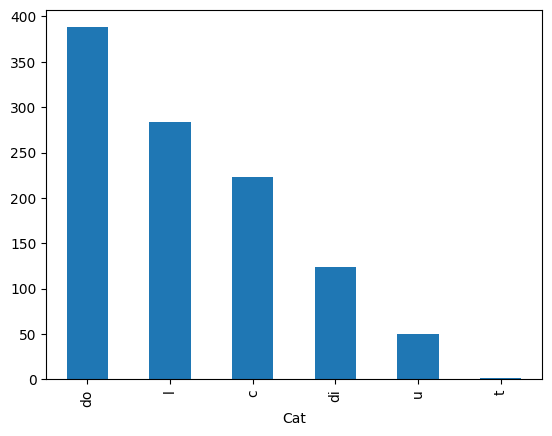

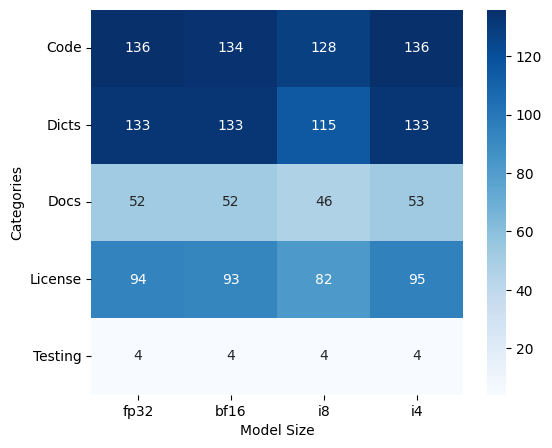

In [11]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep0_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'i8', 'i4'], rotation=0)


# Show the plot
plt.show()

#### Barplot stacked

In [12]:
pre = tot_tags_pre['bf16_ep0_p100_em'].loc[['c', 'di', 'do', 'l', 't']]

In [13]:
ep0_cat['bf16']

Cat
c     134
di    133
do     52
l      93
t       4
Name: bf16, dtype: int64

#### With the percentages, compared to the total number of tags for each category

In [14]:
ep0_cat_15b = (pre_training_tags[pre_training_tags['15b_ep0_p100_em'] == 1 ][['15b_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_bf16 = (pre_training_tags[pre_training_tags['bf16_ep0_p100_em'] == 1 ][['bf16_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_i8 = (pre_training_tags[pre_training_tags['i8_ep0_p100_em'] == 1 ][['i8_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_i4 = (pre_training_tags[pre_training_tags['i4_ep0_p100_em'] == 1 ][['i4_ep0_p100_em', 'Cat']].groupby('Cat').count() )

ep0_cat_15b['15b_ep0_p100_em'] = ep0_cat_15b['15b_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100

ep0_cat_bf16['bf16_ep0_p100_em'] = ep0_cat_bf16['bf16_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep0_cat_i8['i8_ep0_p100_em'] = ep0_cat_i8['i8_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep0_cat_i4['i4_ep0_p100_em'] = ep0_cat_i4['i4_ep0_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100


ep0_cat_perc = ep0_cat_15b.join(ep0_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep0_cat_i8, rsuffix='_i8').join(ep0_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat_perc = ep0_cat_perc.rename(columns={'15b_ep0_p100_em': 'fp32',
                                  'bf16_ep0_p100_em': 'bf16',
                                  'i8_ep0_p100_em': 'i8',
                                  'i4_ep0_p100_em': 'i4'})
ep0_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,35.051546,34.536082,35.051546,32.989691
di,81.097561,81.097561,81.097561,70.121951
do,30.057803,30.057803,30.635838,26.589595
l,75.806452,75.000000,76.612903,66.129032
t,8.000000,8.000000,8.000000,8.000000


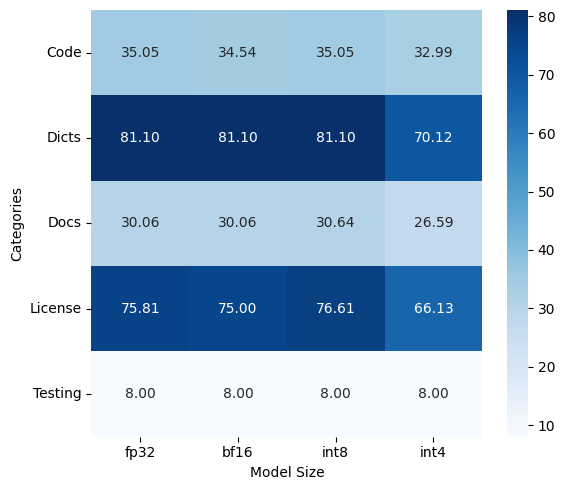

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))  # Adjust the size as needed
# Create the heatmap
ax = sns.heatmap(ep0_cat_perc, annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)

# Adjust the layout to make sure everything fits
plt.tight_layout()


# Show the plot
plt.show()
fig.savefig('./tag_mem_ptrain_perc.pdf', format='pdf')

### Samples memorized per model size and categories - fine-tune model attack

#### Heatmap absolute values

In [16]:
ep3_cat_15b = pre_training_tags[pre_training_tags['15b_ep3_p100_em'] == 1 ][['15b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep3_p100_em'] == 1 ][['bf16_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = pre_training_tags[pre_training_tags['i8_ep3_p100_em'] == 1 ][['i8_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = pre_training_tags[pre_training_tags['i4_ep3_p100_em'] == 1 ][['i4_ep3_p100_em', 'Cat']].groupby('Cat').count()

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_p100_em': 'fp32', 'bf16_ep3_p100_em': 'bf16', 'i8_ep3_p100_em': 'i8', 'i4_ep3_p100_em': 'i4'})

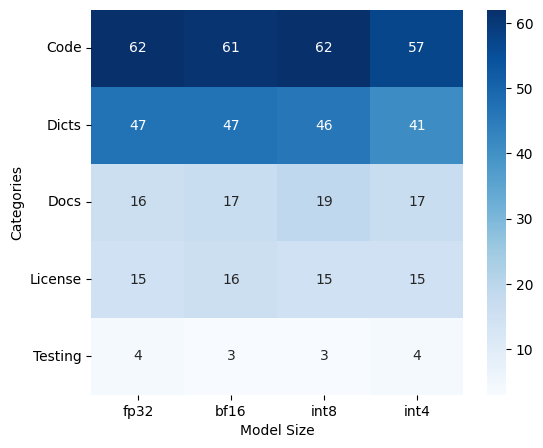

In [17]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)


# Show the plot
plt.show()

Percentage variation

In [18]:
((ep3_cat-ep0_cat)/ep0_cat)*100

,bf16,fp32,i4,i8
Cat,,,,
c,-54.477612,-54.411765,-55.468750,-54.411765
di,-64.661654,-64.661654,-64.347826,-65.413534
do,-67.307692,-69.230769,-63.043478,-64.150943
l,-82.795699,-84.042553,-81.707317,-84.210526
t,-25.000000,0.000000,0.000000,-25.000000


#### With the percentages, compared to the total number of tags for each category

In [19]:
ep3_cat_15b = pre_training_tags[pre_training_tags['15b_ep3_p100_em'] == 1 ][['15b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = pre_training_tags[pre_training_tags['bf16_ep3_p100_em'] == 1 ][['bf16_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = pre_training_tags[pre_training_tags['i8_ep3_p100_em'] == 1 ][['i8_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = pre_training_tags[pre_training_tags['i4_ep3_p100_em'] == 1 ][['i4_ep3_p100_em', 'Cat']].groupby('Cat').count()

ep3_cat_15b['15b_ep3_p100_em'] = ep3_cat_15b['15b_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_bf16['bf16_ep3_p100_em'] = ep3_cat_bf16['bf16_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_i8['i8_ep3_p100_em'] = ep3_cat_i8['i8_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100
ep3_cat_i4['i4_ep3_p100_em'] = ep3_cat_i4['i4_ep3_p100_em'] / tot_tags_pre['bf16_ep0_p100_em'] * 100

ep3_cat_perc = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat_perc = ep3_cat_perc.rename(columns={'15b_ep3_p100_em': 'fp32', 'bf16_ep3_p100_em': 'bf16', 'i8_ep3_p100_em': 'i8', 'i4_ep3_p100_em': 'i4'})
ep3_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,15.979381,15.721649,15.979381,14.690722
di,28.658537,28.658537,28.048780,25.000000
do,9.248555,9.826590,10.982659,9.826590
l,12.096774,12.903226,12.096774,12.096774
t,8.000000,6.000000,6.000000,8.000000


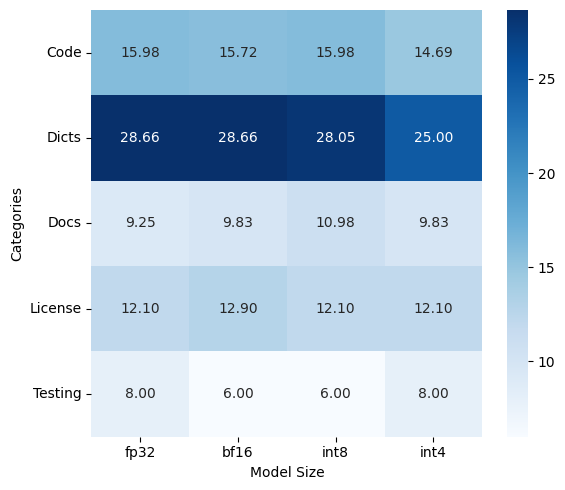

In [20]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat_perc, annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model Size')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)


plt.tight_layout()
# Show the plot
plt.show()

## Put the percentages in one single plot:

In [21]:
ep0_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,35.051546,34.536082,35.051546,32.989691
di,81.097561,81.097561,81.097561,70.121951
do,30.057803,30.057803,30.635838,26.589595
l,75.806452,75.000000,76.612903,66.129032
t,8.000000,8.000000,8.000000,8.000000


In [22]:
ep3_cat_perc

,fp32,bf16,i8,i4
Cat,,,,
c,15.979381,15.721649,15.979381,14.690722
di,28.658537,28.658537,28.048780,25.000000
do,9.248555,9.826590,10.982659,9.826590
l,12.096774,12.903226,12.096774,12.096774
t,8.000000,6.000000,6.000000,8.000000


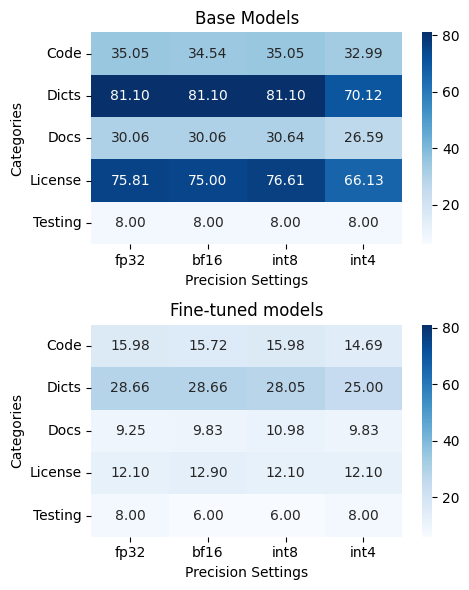

In [23]:
# Use the precision-level data (from cells 24 and 33)
ep0_cat_perc_prec = ep0_cat_perc  # This is already the precision-level data from cell 24
ep3_cat_perc_prec = ep3_cat_perc  # This is already the precision-level data from cell 33

# Determine the global min and max values for the color scale
vmin = min(ep0_cat_perc_prec.min().min(), ep3_cat_perc_prec.min().min())
vmax = max(ep0_cat_perc_prec.max().max(), ep3_cat_perc_prec.max().max())

# Create subplots with a vertical stack
fig, axes = plt.subplots(2, 1, figsize=(5, 6))  # Adjust figsize for vertical layout

# Plot the first heatmap
sns.heatmap(ep0_cat_perc_prec, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title('Base Models')
axes[0].set_ylabel('Categories')
axes[0].set_xlabel('Precision Settings')
axes[0].set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[0].set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)

# Plot the second heatmap
sns.heatmap(ep3_cat_perc_prec, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title('Fine-tuned models')
axes[1].set_ylabel('Categories')
axes[1].set_xlabel('Precision Settings')
axes[1].set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[1].set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)

plt.tight_layout()
# Save the plot as a PDF
plt.savefig('./quant_attack_mem_prec.pdf', format='pdf')
# Show the plot
plt.show()

Total tags fine-tuning samples

In [24]:
fine_tuning_tags.columns

Index(['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       'bf16_ep0_d3', 'bf16_ep0_d3_em', 'bf16_ep0_d3_bleu',
       'bf16_ep0_d3_meteor', 'bf16_ep0_d3_rougeL', 'bf16_ep3_d3',
       'bf16_ep3_d3_em', 'bf16_ep3_d3_bleu', 'bf16_ep3_d3_meteor',
       'bf16_ep3_d3_rougeL', 'i8_ep0_d3', 'i8_ep0_d3_em', 'i8_ep0_d3_bleu',
       'i8_ep0_d3_meteor', 'i8_ep0_d3_rougeL', 'i8_ep3_d3', 'i8_ep3_d3_em',
       'i8_ep3_d3_bleu', 'i8_ep3_d3_meteor', 'i8_ep3_d3_rougeL', 'i4_ep0_d3',
       'i4_ep0_d3_em', 'i4_ep0_d3_bleu', 'i4_ep0_d3_meteor',
       'i4_ep0_d3_rougeL', 'i4_ep3_d3', 'i4_ep3_d3_em', 'i4_ep3_d3_bleu',
       'i4_ep3_d3_meteor', 'i4_ep3_d3_rougeL', '15b_ep0_d3', '15b_ep0_d3_em',
       '15b_ep0_d3_bleu', '15b_ep0_d3_meteor', '15b_ep0_d3_rougeL',
       '15b_ep3_d3', '15b_ep3_d3_em', '15b_ep3_d3_bleu', '15b_ep3_d3_meteor',
       '15b_ep3_d3_rougeL', 'eval_sample', 'Cat', 'Interesting', 'agree'],
      dtype='object')

In [25]:
tot_tags_tune = fine_tuning_tags[['15b_ep0_d3_em', 'Cat']].groupby('Cat').count()
tot_tags_tune

,15b_ep0_d3_em
Cat,
c,223
di,117
do,291
l,284
t,2
u,8


### Absolute values

In [26]:
ep3_cat_15b = fine_tuning_tags[fine_tuning_tags['15b_ep3_d3_em'] == 1 ][['15b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = fine_tuning_tags[fine_tuning_tags['bf16_ep3_d3_em'] == 1 ][['bf16_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = fine_tuning_tags[fine_tuning_tags['i8_ep3_d3_em'] == 1 ][['i8_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = fine_tuning_tags[fine_tuning_tags['i4_ep3_d3_em'] == 1 ][['i4_ep3_d3_em', 'Cat']].groupby('Cat').count()

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_d3_em': 'fp32', 'bf16_ep3_d3_em': 'bf16', 'i8_ep3_d3_em': 'i8', 'i4_ep3_d3_em': 'i4'})
ep3_cat

,fp32,bf16,i8,i4
Cat,,,,
c,88,87,89,77
di,64,65,63,67
do,137,137,136,117
l,195,196,196,192
t,1,1,1,1


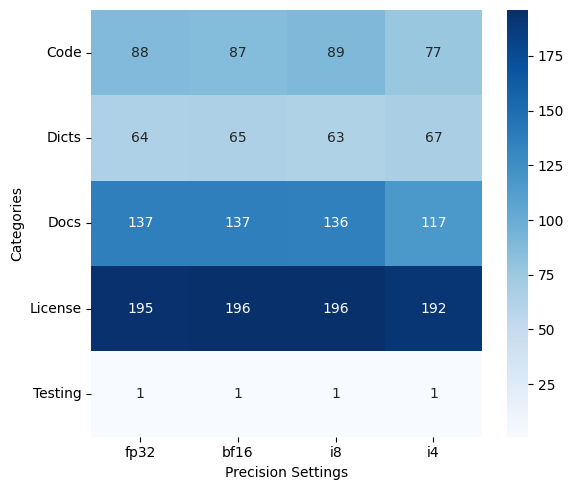

In [27]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Precision Settings')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
axes[1].set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)

fig.tight_layout()
# Show the plot
plt.show()

### With the percentages, compared to the total number of tags for each category

In [28]:
ep3_cat_15b = fine_tuning_tags[fine_tuning_tags['15b_ep3_d3_em'] == 1 ][['15b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_bf16 = fine_tuning_tags[fine_tuning_tags['bf16_ep3_d3_em'] == 1 ][['bf16_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i8 = fine_tuning_tags[fine_tuning_tags['i8_ep3_d3_em'] == 1 ][['i8_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_i4 = fine_tuning_tags[fine_tuning_tags['i4_ep3_d3_em'] == 1 ][['i4_ep3_d3_em', 'Cat']].groupby('Cat').count()

ep3_cat_15b['15b_ep3_d3_em'] = ep3_cat_15b['15b_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_bf16['bf16_ep3_d3_em'] = ep3_cat_bf16['bf16_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_i8['i8_ep3_d3_em'] = ep3_cat_i8['i8_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100
ep3_cat_i4['i4_ep3_d3_em'] = ep3_cat_i4['i4_ep3_d3_em'] / tot_tags_tune['15b_ep0_d3_em'] * 100

ep3_cat = ep3_cat_15b.join(ep3_cat_bf16, lsuffix='_fp32', rsuffix='_bf16').join(ep3_cat_i8, rsuffix='_i8').join(ep3_cat_i4, rsuffix='_i4').loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'15b_ep3_d3_em': 'fp32', 'bf16_ep3_d3_em': 'bf16', 'i8_ep3_d3_em': 'i8', 'i4_ep3_d3_em': 'i4'})

ep3_cat

,fp32,bf16,i8,i4
Cat,,,,
c,39.461883,39.013453,39.910314,34.529148
di,54.700855,55.555556,53.846154,57.264957
do,47.079038,47.079038,46.735395,40.206186
l,68.661972,69.014085,69.014085,67.605634
t,50.000000,50.000000,50.000000,50.000000


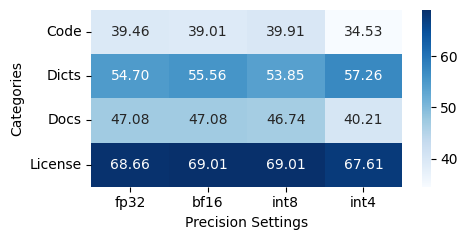

In [29]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat.loc[['c', 'di', 'do', 'l']], annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Precision Settings')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License'], rotation=0)
ax.set_xticklabels(['fp32', 'bf16', 'int8', 'int4'], rotation=0)

fig.tight_layout()
# Show the plot
plt.show()
fig.savefig('./quant-tag_mem_ftune_perc.pdf', format='pdf')

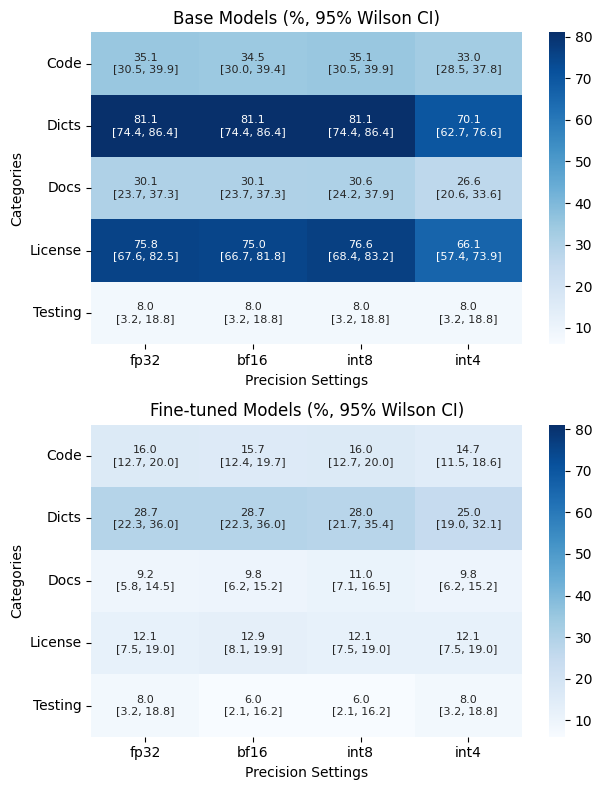

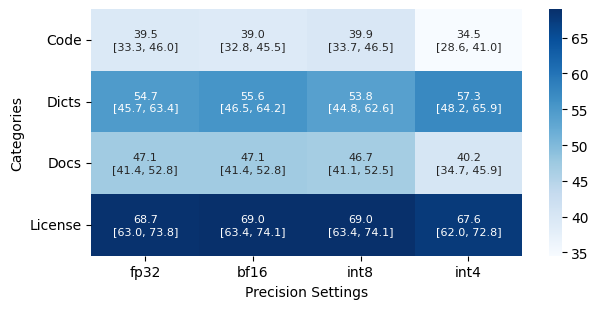

In [30]:
# Dedicated CI heatmaps (finale) for percentage plots
cat_order_pre = ['c', 'di', 'do', 'l', 't']
cat_labels_pre = ['Code', 'Dicts', 'Docs', 'License', 'Testing']
cat_order_ft = ['c', 'di', 'do', 'l']
cat_labels_ft = ['Code', 'Dicts', 'Docs', 'License']
model_labels = ['fp32', 'bf16', 'int8', 'int4']


def _build_perc_and_ci(df, col_by_model, denominator_by_cat, cat_order):
    perc = pd.DataFrame(index=cat_order, columns=model_labels, dtype=float)
    ci_low = pd.DataFrame(index=cat_order, columns=model_labels, dtype=float)
    ci_high = pd.DataFrame(index=cat_order, columns=model_labels, dtype=float)

    for cat in cat_order:
        nobs = denominator_by_cat.get(cat, np.nan)
        if pd.isna(nobs) or int(nobs) <= 0:
            continue
        nobs = int(nobs)
        cat_df = df[df['Cat'] == cat]

        for model_label, metric_col in col_by_model.items():
            successes = int((cat_df[metric_col] == 1).sum())
            low, high = wilson_confint(successes, nobs, alpha=0.05)
            perc.loc[cat, model_label] = successes / nobs * 100.0
            ci_low.loc[cat, model_label] = low * 100.0
            ci_high.loc[cat, model_label] = high * 100.0

    return perc, ci_low, ci_high


def _annotation_text(perc, ci_low, ci_high, decimals=1):
    annot = pd.DataFrame(index=perc.index, columns=perc.columns, dtype=object)
    for row in perc.index:
        for col in perc.columns:
            value = perc.loc[row, col]
            if pd.isna(value):
                annot.loc[row, col] = '-'
            else:
                annot.loc[row, col] = (
                    f"{value:.{decimals}f}\n"
                    f"[{ci_low.loc[row, col]:.{decimals}f}, {ci_high.loc[row, col]:.{decimals}f}]"
                )
    return annot


# --- Pre-train percentages with CI (EP0 and EP3) ---
den_pre = tot_tags_pre['bf16_ep0_p100_em'].reindex(cat_order_pre)
pre_ep0_cols = {
    'fp32': '15b_ep0_p100_em',
    'bf16': 'bf16_ep0_p100_em',
    'int8': 'i8_ep0_p100_em',
    'int4': 'i4_ep0_p100_em',
}
pre_ep3_cols = {
    'fp32': '15b_ep3_p100_em',
    'bf16': 'bf16_ep3_p100_em',
    'int8': 'i8_ep3_p100_em',
    'int4': 'i4_ep3_p100_em',
}

ep0_perc_ci, ep0_low_ci, ep0_high_ci = _build_perc_and_ci(
    pre_training_tags,
    pre_ep0_cols,
    den_pre,
    cat_order_pre,
)
ep3_perc_ci, ep3_low_ci, ep3_high_ci = _build_perc_and_ci(
    pre_training_tags,
    pre_ep3_cols,
    den_pre,
    cat_order_pre,
)

ep0_annot = _annotation_text(ep0_perc_ci, ep0_low_ci, ep0_high_ci, decimals=1)
ep3_annot = _annotation_text(ep3_perc_ci, ep3_low_ci, ep3_high_ci, decimals=1)

vmin_pre = float(np.nanmin([ep0_perc_ci.min().min(), ep3_perc_ci.min().min()]))
vmax_pre = float(np.nanmax([ep0_perc_ci.max().max(), ep3_perc_ci.max().max()]))

fig, axes = plt.subplots(2, 1, figsize=(6.5, 8))
sns.heatmap(
    ep0_perc_ci,
    annot=ep0_annot,
    fmt='',
    cmap='Blues',
    cbar=True,
    ax=axes[0],
    vmin=vmin_pre,
    vmax=vmax_pre,
    annot_kws={'fontsize': 8},
)
axes[0].set_title('Base Models (%, 95% Wilson CI)')
axes[0].set_ylabel('Categories')
axes[0].set_xlabel('Precision Settings')
axes[0].set_yticklabels(cat_labels_pre, rotation=0)
axes[0].set_xticklabels(model_labels, rotation=0)

sns.heatmap(
    ep3_perc_ci,
    annot=ep3_annot,
    fmt='',
    cmap='Blues',
    cbar=True,
    ax=axes[1],
    vmin=vmin_pre,
    vmax=vmax_pre,
    annot_kws={'fontsize': 8},
)
axes[1].set_title('Fine-tuned Models (%, 95% Wilson CI)')
axes[1].set_ylabel('Categories')
axes[1].set_xlabel('Precision Settings')
axes[1].set_yticklabels(cat_labels_pre, rotation=0)
axes[1].set_xticklabels(model_labels, rotation=0)

plt.tight_layout()
fig.savefig('./quant-tag_mem_ptrain_perc_with_ci_finale.pdf', format='pdf')
plt.show()


# --- Fine-tune percentages with CI (EP3, d3) ---
den_ft = tot_tags_tune['15b_ep0_d3_em'].reindex(cat_order_ft)
ft_ep3_cols = {
    'fp32': '15b_ep3_d3_em',
    'bf16': 'bf16_ep3_d3_em',
    'int8': 'i8_ep3_d3_em',
    'int4': 'i4_ep3_d3_em',
}

ft_perc_ci, ft_low_ci, ft_high_ci = _build_perc_and_ci(
    fine_tuning_tags,
    ft_ep3_cols,
    den_ft,
    cat_order_ft,
)
ft_annot = _annotation_text(ft_perc_ci, ft_low_ci, ft_high_ci, decimals=1)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
sns.heatmap(
    ft_perc_ci,
    annot=ft_annot,
    fmt='',
    cmap='Blues',
    cbar=True,
    ax=ax,
    annot_kws={'fontsize': 8},
)
ax.set_ylabel('Categories')
ax.set_xlabel('Precision Settings')
ax.set_yticklabels(cat_labels_ft, rotation=0)
ax.set_xticklabels(model_labels, rotation=0)

fig.tight_layout()
fig.savefig('./quant-tag_mem_ftune_perc_with_ci_finale.pdf', format='pdf')
plt.show()
